# SMAP L3 Soil Moisture Increase Dates – Per Rainfall Class

This notebook mirrors the logic of `SPL3SMP_E_calib_dates_no_class.ipynb` but applies the spatial increase filter **independently for each rainfall class** (1–5).

For each class a date is retained if **≥ 75 % of the stations inside that class** show a soil-moisture increase.  
Consecutive increasing days are then grouped into events and expanded with a configurable pre/post-event window.  
Results are saved to individual CSV files inside `smap_calib_dates_per_class/`.

## 1 · Import Libraries

In [14]:
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from datetime import datetime, timedelta
import warnings
import os

warnings.filterwarnings('ignore')
# os.chdir('/master_storage6/ishan/my_data/SSM-irrigation-data/SMAP')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2 · Configuration

In [15]:
# ── Input files ──────────────────────────────────────────────────────────────
type_name = "ludhiana" # "validate"
DATA_FILE     = Path(r'G:\SM2RAIN-irrigation_Final\data\SMAP_data\SPL3SMP_E_Ludhiana_ROI.nc')
CLASS_CSV     = Path(rf'G:\SM2RAIN-irrigation_Final\calibration\SM_classes\SM_classes_{type_name}.csv')

# ── Output directory (one CSV per class will be written here) ────────────────
OUTPUT_DIR    = Path(fr'G:\SM2RAIN-irrigation_Final\calibration\calib_dates_{type_name}')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Date range to analyse ────────────────────────────────────────────────────
START_DATE    = '2015-01-01'
STOP_DATE     = '2025-12-31'

# ── Soil-moisture source ─────────────────────────────────────────────────────
SM_SOURCE     = 'BOTH'   # 'AM' | 'PM' | 'BOTH'
FILL_VALUE    = -9999.0

# ── Per-class spatial filter ─────────────────────────────────────────────────
CUTOFF_FRACTION   = 0.3   # 75 % of stations in a class must be increasing

# ── Increase threshold (daily SM change, m³/m³) ──────────────────────────────
INCREASE_THRESHOLD = 0.02

# ── Event-window expansion ───────────────────────────────────────────────────
DAYS_BEFORE_START  = 2    # days of "dry baseline" to prepend to each event
DAYS_AFTER_END     = 2    # days of "drainage tail" to append to each event

print('Configuration:')
print(f'  SMAP NC file   : {DATA_FILE}')
print(f'  Class CSV      : {CLASS_CSV}')
print(f'  Output dir     : {OUTPUT_DIR}')
print(f'  Date range     : {START_DATE}  →  {STOP_DATE}')
print(f'  SM source      : {SM_SOURCE}')
print(f'  Cutoff fraction: {CUTOFF_FRACTION:.0%}')
print(f'  Increase thresh: {INCREASE_THRESHOLD} m³/m³')
print(f'  Window         : -{DAYS_BEFORE_START} / +{DAYS_AFTER_END} days')

Configuration:
  SMAP NC file   : G:\SM2RAIN-irrigation_Final\data\SMAP_data\SPL3SMP_E_Ludhiana_ROI.nc
  Class CSV      : G:\SM2RAIN-irrigation_Final\calibration\SM_classes\SM_classes_ludhiana.csv
  Output dir     : G:\SM2RAIN-irrigation_Final\calibration\calib_dates_ludhiana
  Date range     : 2015-01-01  →  2025-12-31
  SM source      : BOTH
  Cutoff fraction: 30%
  Increase thresh: 0.02 m³/m³
  Window         : -2 / +2 days


## 3 · Load SMAP NetCDF and Build the Full Daily Pivot Table

In [16]:
if not DATA_FILE.exists():
    raise FileNotFoundError(f'SMAP file not found: {DATA_FILE}')

print(f'Opening: {DATA_FILE}')
ds = nc.Dataset(DATA_FILE, 'r')

epoch    = datetime(2000, 1, 1)
time_dt  = np.array([epoch + timedelta(seconds=float(t)) for t in ds.variables['time'][:]])
latitude         = ds.variables['latitude'][:]
longitude        = ds.variables['longitude'][:]
soil_moisture_am = ds.variables['soil_moisture_am'][:]
soil_moisture_pm = ds.variables['soil_moisture_pm'][:]
ds.close()

# Build raw DataFrame
df = pd.DataFrame({
    'time'            : time_dt,
    'latitude'        : latitude,
    'longitude'       : longitude,
    'soil_moisture_am': soil_moisture_am,
    'soil_moisture_pm': soil_moisture_pm,
})

# Remove fill-value rows
df = df[(df['latitude']  != FILL_VALUE) & (df['longitude'] != FILL_VALUE)]
df = df[(df['soil_moisture_am'] != FILL_VALUE) | (df['soil_moisture_pm'] != FILL_VALUE)]

# Compute combined soil-moisture
if SM_SOURCE == 'AM':
    df['soil_moisture'] = df['soil_moisture_am'].replace(FILL_VALUE, np.nan)
elif SM_SOURCE == 'PM':
    df['soil_moisture'] = df['soil_moisture_pm'].replace(FILL_VALUE, np.nan)
else:
    sm_am = df['soil_moisture_am'].replace(FILL_VALUE, np.nan)
    sm_pm = df['soil_moisture_pm'].replace(FILL_VALUE, np.nan)
    df['soil_moisture'] = np.nanmean([sm_am, sm_pm], axis=0)

df = df.dropna(subset=['soil_moisture'])
df = df[(df['time'] >= START_DATE) & (df['time'] <= STOP_DATE)]

# Build a string station key  "lat4dp_lon4dp"  to avoid float equality issues
# when matching between DataFrames later (tuples of floats are unreliable).
df['lat_r'] = df['latitude'].round(4)
df['lon_r'] = df['longitude'].round(4)
df['station'] = df['lat_r'].map(lambda x: f'{x:.4f}') + '_' + \
                df['lon_r'].map(lambda x: f'{x:.4f}')

# Daily average per station
df['date'] = pd.to_datetime(df['time']).dt.date

daily = (
    df.groupby(['station', 'date'], as_index=False)
      .agg(sm_mean=('soil_moisture', 'mean'))
)
daily['date'] = pd.to_datetime(daily['date'])

# Full pivot: rows = date, columns = station string keys
ts_full = daily.pivot_table(index='date', columns='station', values='sm_full' if False else 'sm_mean')
ts_full.columns.name = None
ts_full = ts_full.sort_index()

print(f'Valid observations  : {len(df):,}')
print(f'Date range          : {ts_full.index[0].date()}  →  {ts_full.index[-1].date()}')
print(f'Total dates         : {len(ts_full)}')
print(f'Total unique stations: {len(ts_full.columns)}')
print(f'Sample station keys : {list(ts_full.columns[:4])}')


Opening: G:\SM2RAIN-irrigation_Final\data\SMAP_data\SPL3SMP_E_Ludhiana_ROI.nc
Valid observations  : 288,684
Date range          : 2015-04-03  →  2025-12-31
Total dates         : 1869
Total unique stations: 156
Sample station keys : ['30.0269_75.0156', '30.0269_75.1089', '30.0269_75.2023', '30.0269_75.2956']


## 4 · Load Class Assignments and Map Stations to Classes

In [17]:
class_df = pd.read_csv(CLASS_CSV)

# Build the same string station key used in the pivot table
class_df['lat_r'] = class_df['latitude'].round(4)
class_df['lon_r'] = class_df['longitude'].round(4)
class_df['station'] = class_df['lat_r'].map(lambda x: f'{x:.4f}') + '_' + \
                      class_df['lon_r'].map(lambda x: f'{x:.4f}')

# Map station string key → class
station_class_map = dict(zip(class_df['station'], class_df['rainfall_class']))

# Build per-class station lists (intersect with stations present in the pivot)
pivot_stations = set(ts_full.columns)
classes = sorted(class_df['rainfall_class'].unique())

class_stations = {}
for cls in classes:
    stations = [s for s, c in station_class_map.items()
                if c == cls and s in pivot_stations]
    class_stations[cls] = stations
    print(f'  Class {cls}: {len(stations):>3} stations')

# Stations in the pivot but missing from the class CSV
missing = pivot_stations - set(station_class_map.keys())
if missing:
    print(f'\n  ⚠  {len(missing)} pivot stations have no class assignment (will be ignored)')
    for s in sorted(list(missing))[:5]:
        print(f'     {s}')
else:
    print('\n  ✓ All pivot stations have a class assignment.')


  Class 1:  25 stations
  Class 2:  16 stations
  Class 3:  42 stations
  Class 4:  41 stations
  Class 5:  32 stations

  ✓ All pivot stations have a class assignment.


## 5 · Helper – Event Detection Function

In [18]:
def detect_calibration_dates(ts_class, cutoff, increase_thresh,
                              days_before, days_after, class_label):
    """
    Given a date × station pivot table for ONE class, return a sorted
    DatetimeIndex of calibration dates (with pre/post window expansion).

    Parameters
    ----------
    ts_class        : pd.DataFrame  – pivot (date index, station columns)
    cutoff          : float         – fraction of stations that must be increasing
    increase_thresh : float         – minimum daily SM change (m³/m³)
    days_before     : int           – baseline days to prepend to each event
    days_after      : int           – tail days to append to each event
    class_label     : int/str       – used only for diagnostic printing

    Returns
    -------
    final_dates       : pd.DatetimeIndex  – all dates (events + window)
    events            : list of lists     – grouped consecutive observation blocks
    calibration_dates : pd.DatetimeIndex  – raw SM-increase dates (before expansion)

    Key design decisions
    --------------------
    * ts_class inherits ALL rows of ts_full, including dates where every station
      in this class is NaN (because another class had data that day).  These
      "ghost" rows must be dropped BEFORE computing diff() and before building
      obs_dates / next_obs.  Without this:
        – diff() at the first real row after a ghost row compares against NaN
          → NaN diff → the row is never flagged as increasing, even when SM
          clearly rose since the previous real observation.
        – next_obs[real_date] points to the ghost date, not the next real
          observation, so consecutive wetting passes are never grouped into the
          same event.
    * The denominator for the fraction-of-stations must be the number of
      stations with a valid *diff* on that date (daily_diff.count), not the
      number with a valid raw SM value (ts_class.count). These differ on the
      first observation a station reports (diff is NaN there even though SM is
      valid).
    """
    if ts_class.empty or ts_class.shape[1] == 0:
        print(f'  Class {class_label}: no stations – skipping.')
        return pd.DatetimeIndex([]), [], pd.DatetimeIndex([])

    # ── Drop rows where ALL class stations are NaN ("ghost" rows inherited from
    #    ts_full that belong to other classes' observation dates only) ──────────
    ts_class = ts_class.dropna(how='all')

    if ts_class.empty:
        print(f'  Class {class_label}: all rows NaN after cleaning – skipping.')
        return pd.DatetimeIndex([]), [], pd.DatetimeIndex([])

    # ── Sorted real observation dates for this class ──────────────────────────
    obs_dates = ts_class.index.sort_values().tolist()

    # Map each observation date to the NEXT real observation (O(1) lookup).
    next_obs = {obs_dates[i]: obs_dates[i + 1] for i in range(len(obs_dates) - 1)}

    # Print observed spacing to help the user validate
    gaps = [(obs_dates[i+1] - obs_dates[i]).days for i in range(min(10, len(obs_dates)-1))]
    print(f'  Class {class_label}: typical obs spacing (first 10 gaps) = {gaps} days')

    # ── Daily change vs. previous real observation ────────────────────────────
    # After dropna(how='all'), diff() compares each row only against the
    # previous row that exists in the (now clean) pivot.
    daily_diff = ts_class.diff()

    # Stations increasing by at least the threshold on this observation
    is_increasing = daily_diff >= increase_thresh

    # ── Use diff counts as denominator (not raw SM counts) ───────────────────
    # A station's diff is NaN on its very first observation even though SM is
    # valid.  Using daily_diff.count() avoids artificially inflating the
    # denominator and pushing the fraction below the cutoff.
    valid_counts = daily_diff.count(axis=1)

    # Fraction of diff-valid stations that are increasing
    event_counts    = is_increasing.sum(axis=1)
    daily_fractions = event_counts.div(valid_counts).fillna(0.0)

    # Raw calibration dates (≥ cutoff fraction of stations increasing)
    calibration_dates = daily_fractions[daily_fractions >= cutoff].index

    # ── Group consecutive *observations* into events ──────────────────────────
    sorted_dates = sorted(list(calibration_dates))
    events = []
    if sorted_dates:
        current_event = [sorted_dates[0]]
        for i in range(1, len(sorted_dates)):
            prev = sorted_dates[i - 1]
            curr = sorted_dates[i]
            # Adjacent real observation → same rain/wetting event
            if next_obs.get(prev) == curr:
                current_event.append(curr)
            else:
                events.append(current_event)
                current_event = [curr]
        events.append(current_event)

    # ── Expand each event with pre/post calendar-day window ───────────────────
    expanded = set()
    t_min, t_max = obs_dates[0], obs_dates[-1]

    for event in events:
        for d in range(1, days_before + 1):
            bd = event[0] - pd.Timedelta(days=d)
            if bd >= t_min:
                expanded.add(bd)
        for date in event:
            expanded.add(date)
        for d in range(1, days_after + 1):
            td = event[-1] + pd.Timedelta(days=d)
            if td <= t_max:
                expanded.add(td)

    final_dates = pd.DatetimeIndex(sorted(list(expanded)))

    print(f'  Class {class_label}: {len(ts_class.columns)} stations | '
          f'{len(calibration_dates)} raw dates → {len(events)} events → '
          f'{len(final_dates)} window dates')

    return final_dates, events, calibration_dates


print('Helper function defined.')


Helper function defined.


## 6 · Run Detection for Each Class and Save CSVs

In [19]:
results = {}   # class → dict with final_dates, events, raw calibration_dates

print('Running per-class event detection...')
print(f'  Cutoff fraction  : {CUTOFF_FRACTION:.0%}')
print(f'  Increase threshold: {INCREASE_THRESHOLD} m³/m³')
print(f'  Window           : {DAYS_BEFORE_START} day(s) before, {DAYS_AFTER_END} day(s) after')
print(f'\n  Flag legend: 1 = SM increase date  |  0 = window date (pre/post event)')
print()

for cls in classes:
    stations = class_stations[cls]
    if not stations:
        print(f'  Class {cls}: no stations with valid data – skipped.')
        continue

    # Slice the full pivot to only columns belonging to this class
    ts_class = ts_full[stations].copy()

    final_dates, events, calib_dates = detect_calibration_dates(
        ts_class,
        cutoff          = CUTOFF_FRACTION,
        increase_thresh = INCREASE_THRESHOLD,
        days_before     = DAYS_BEFORE_START,
        days_after      = DAYS_AFTER_END,
        class_label     = cls,
    )

    results[cls] = {
        'final_dates'  : final_dates,
        'events'       : events,
        'calib_dates'  : calib_dates,
        'n_stations'   : len(stations),
    }

    # ── Build rows matching the 4-1_SMAP_rainfall_filter.ipynb schema ────────
    # Columns: event_date, date, offset_days, flag
    #   event_date  = first date of the consecutive SM-increase block
    #   date        = each calendar day in the expanded window
    #   offset_days = (date – event_date).days
    #   flag        = 1 if the date is a raw SM-increase date, 0 otherwise
    # ─────────────────────────────────────────────────────────────────────────
    calib_set = set(calib_dates)
    t_min = ts_class.dropna(how='all').index.min() if len(ts_class.dropna(how='all')) > 0 else None
    t_max = ts_class.dropna(how='all').index.max() if len(ts_class.dropna(how='all')) > 0 else None

    rows = []
    seen_dates = set()
    for event in events:
        event_date_label = event[0]          # representative "event_date" for this block
        event_flag1_set  = set(event)        # raw SM-increase dates in this event

        out_start = event[0]  - pd.Timedelta(days=DAYS_BEFORE_START)
        out_end   = event[-1] + pd.Timedelta(days=DAYS_AFTER_END)

        # Clip to available data range
        if t_min is not None:
            out_start = max(out_start, t_min)
        if t_max is not None:
            out_end   = min(out_end,   t_max)

        d = out_start
        while d <= out_end:
            if d not in seen_dates:
                seen_dates.add(d)
                rows.append({
                    'event_date' : event_date_label,
                    'date'       : d,
                    'offset_days': (d - event_date_label).days,
                    'flag'       : 1 if d in event_flag1_set else 0,
                })
            d += pd.Timedelta(days=1)

    # Save CSV
    out_csv = OUTPUT_DIR / f'class_{cls}_calib_dates.csv'
    out_df = pd.DataFrame(rows)
    if not out_df.empty:
        out_df['event_date'] = pd.to_datetime(out_df['event_date']).dt.strftime('%Y-%m-%d')
        out_df['date']       = pd.to_datetime(out_df['date']).dt.strftime('%Y-%m-%d')
    out_df.to_csv(out_csv, index=False)

print()
print('=== Summary ===')
for cls in classes:
    if cls in results:
        r = results[cls]
        out_csv = OUTPUT_DIR / f'class_{cls}_calib_dates.csv'
        n_increase = len(r['calib_dates'])
        n_window   = len(r['final_dates']) - n_increase
        print(f'  Class {cls}  |  {r["n_stations"]:>3} stations  |  '
              f'{n_increase:>4} increase dates (flag=1)  |  '
              f'{n_window:>4} window dates (flag=0)  |  '
              f'{len(r["final_dates"]):>4} total  →  {out_csv.name}')

print()
print(f'All CSVs saved to: {OUTPUT_DIR}')


Running per-class event detection...
  Cutoff fraction  : 30%
  Increase threshold: 0.02 m³/m³
  Window           : 2 day(s) before, 2 day(s) after

  Flag legend: 1 = SM increase date  |  0 = window date (pre/post event)

  Class 1: typical obs spacing (first 10 gaps) = [2, 1, 2, 3, 2, 1, 2, 3, 2, 1] days
  Class 1: 25 stations | 405 raw dates → 292 events → 1493 window dates
  Class 2: typical obs spacing (first 10 gaps) = [2, 1, 2, 3, 2, 1, 2, 3, 2, 1] days
  Class 2: 16 stations | 446 raw dates → 316 events → 1612 window dates
  Class 3: typical obs spacing (first 10 gaps) = [2, 1, 2, 3, 2, 1, 2, 3, 2, 1] days
  Class 3: 42 stations | 450 raw dates → 318 events → 1626 window dates
  Class 4: typical obs spacing (first 10 gaps) = [2, 1, 2, 3, 2, 1, 2, 3, 2, 1] days
  Class 4: 41 stations | 460 raw dates → 324 events → 1654 window dates
  Class 5: typical obs spacing (first 10 gaps) = [2, 1, 2, 3, 2, 1, 2, 3, 2, 1] days
  Class 5: 32 stations | 473 raw dates → 339 events → 1713 windo

## 7 · Inspect Saved Files

In [20]:
for cls in classes:
    csv_path = OUTPUT_DIR / f'class_{cls}_calib_dates.csv'
    if csv_path.exists():
        tmp = pd.read_csv(csv_path, parse_dates=['date', 'event_date'])
        n_flag1 = (tmp['flag'] == 1).sum()
        n_flag0 = (tmp['flag'] == 0).sum()
        print(f'Class {cls}  ({len(tmp)} rows | {n_flag1} flag=1 | {n_flag0} flag=0): '
              f'{tmp["date"].min().date()}  →  {tmp["date"].max().date()}')
        print(f'  Columns : {list(tmp.columns)}')
        print(tmp.head(6).to_string(index=False))
        print()
    else:
        print(f'Class {cls}: file not found (class may have been skipped)')


Class 1  (1623 rows | 405 flag=1 | 1218 flag=0): 2015-04-06  →  2025-12-12
  Columns : ['event_date', 'date', 'offset_days', 'flag']
event_date       date  offset_days  flag
2015-04-08 2015-04-06           -2     0
2015-04-08 2015-04-07           -1     0
2015-04-08 2015-04-08            0     1
2015-04-08 2015-04-09            1     0
2015-04-08 2015-04-10            2     0
2015-04-29 2015-04-27           -2     0

Class 2  (1771 rows | 446 flag=1 | 1325 flag=0): 2015-04-06  →  2025-12-12
  Columns : ['event_date', 'date', 'offset_days', 'flag']
event_date       date  offset_days  flag
2015-04-08 2015-04-06           -2     0
2015-04-08 2015-04-07           -1     0
2015-04-08 2015-04-08            0     1
2015-04-08 2015-04-09            1     0
2015-04-08 2015-04-10            2     0
2015-04-16 2015-04-14           -2     0

Class 3  (1784 rows | 450 flag=1 | 1334 flag=0): 2015-04-06  →  2025-12-12
  Columns : ['event_date', 'date', 'offset_days', 'flag']
event_date       date  of

## 8 · Visualisation – Calendar Heatmap of Calibration Dates per Class

In [21]:
# # Bar-chart: number of calibration dates per month, faceted by class
# n_cls = len([c for c in classes if c in results and len(results[c]['final_dates']) > 0])
# fig, axes = plt.subplots(n_cls, 1, figsize=(14, 3 * n_cls), sharex=False)
# if n_cls == 1:
#     axes = [axes]

# ax_idx = 0
# for cls in classes:
#     if cls not in results or len(results[cls]['final_dates']) == 0:
#         continue

#     dates = pd.Series(results[cls]['final_dates'])
#     monthly = dates.dt.to_period('M').value_counts().sort_index()

#     ax = axes[ax_idx]
#     ax.bar(monthly.index.astype(str), monthly.values,
#            color=plt.cm.RdYlGn(cls / 6), edgecolor='grey', linewidth=0.4)
#     ax.set_title(f'Class {cls}  ({results[cls]["n_stations"]} stations, '
#                  f'{len(results[cls]["final_dates"])} calibration days)',
#                  fontsize=11, fontweight='bold')
#     ax.set_ylabel('Days / month', fontsize=9)
#     ax.tick_params(axis='x', rotation=60, labelsize=7)
#     ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
#     ax.grid(axis='y', alpha=0.3, linestyle='--')
#     ax_idx += 1

# plt.suptitle(
#     f'SMAP Calibration Dates per Rainfall Class\n'
#     f'(≥ {CUTOFF_FRACTION:.0%} stations increasing, SM Δ ≥ {INCREASE_THRESHOLD} m³/m³)',
#     fontsize=13, fontweight='bold', y=1.01
# )
# plt.tight_layout()
# # plt.savefig(OUTPUT_DIR / 'calib_dates_per_class_monthly.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('Plot displayed.')

## 9 · Visualisation – Overlapping Timeline Across All Classes

In [22]:
# fig, ax = plt.subplots(figsize=(16, 4))

# colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(classes)))

# for i, cls in enumerate(classes):
#     if cls not in results or len(results[cls]['final_dates']) == 0:
#         continue
#     dates = results[cls]['final_dates']
#     # Plot as vertical tick marks at row = class index
#     ax.vlines(dates, i - 0.4, i + 0.4, colors=colors[i], linewidth=0.7, alpha=0.7)

# ax.set_yticks(range(len(classes)))
# ax.set_yticklabels([f'Class {c}' for c in classes], fontsize=10)
# ax.set_xlabel('Date', fontsize=11)
# ax.set_title(
#     f'SMAP Calibration Date Windows per Rainfall Class ({START_DATE[:4]}–{STOP_DATE[:4]})',
#     fontsize=12, fontweight='bold'
# )
# ax.grid(axis='x', alpha=0.3, linestyle='--')
# plt.tight_layout()
# # plt.savefig(OUTPUT_DIR / 'calib_dates_timeline.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('Plot displayed.')

## 10 · Consecutive SM-Increase Dates – Per-Class Station Overlay

For each rainfall class the cell below plots every station's daily soil-moisture
time series (viewer style) and shades the **consecutive-increase event blocks**
detected in Section 6.

* **Green shaded band** – entire event window (pre-event baseline + raw increase
  block + post-event tail) that was written to the CSV.
* **Red dashed vertical lines** – individual raw SM-increase dates (flag = 1).


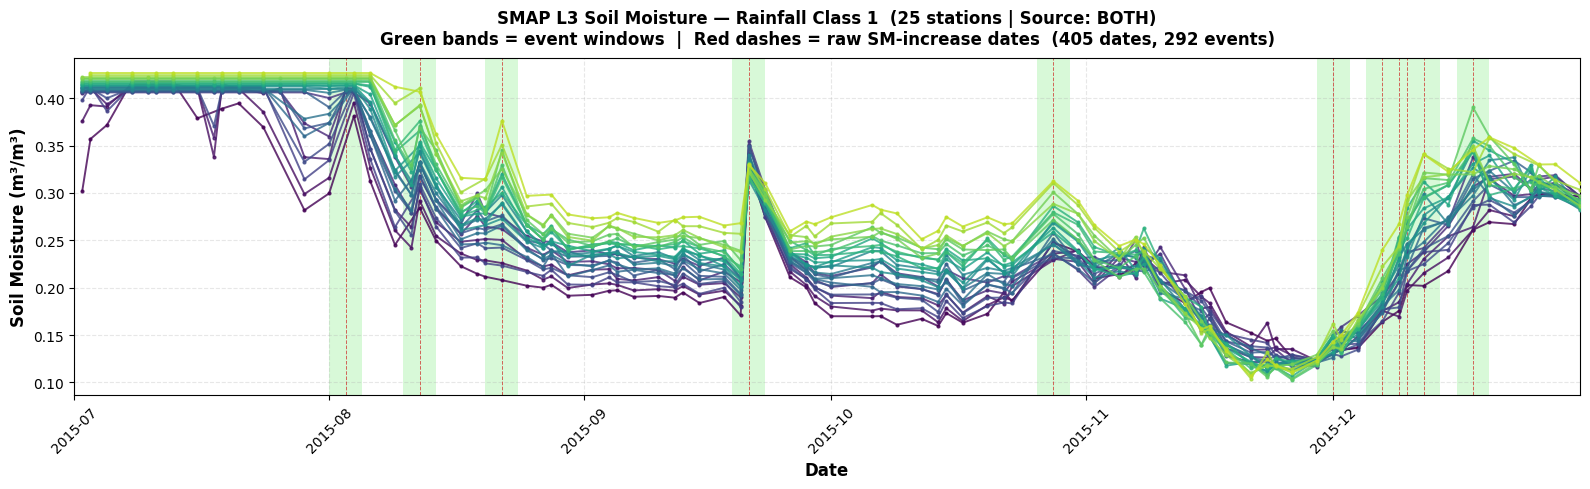

Class 1: 292 consecutive-increase event(s) | 405 raw increase dates | 1493 total window dates



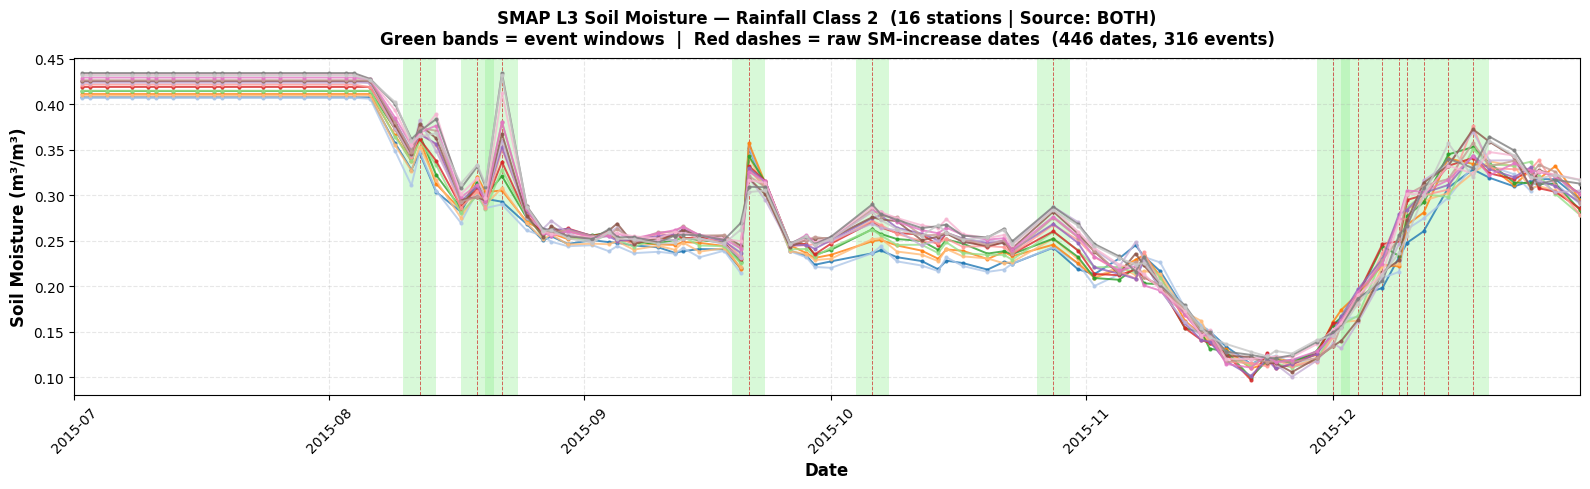

Class 2: 316 consecutive-increase event(s) | 446 raw increase dates | 1612 total window dates



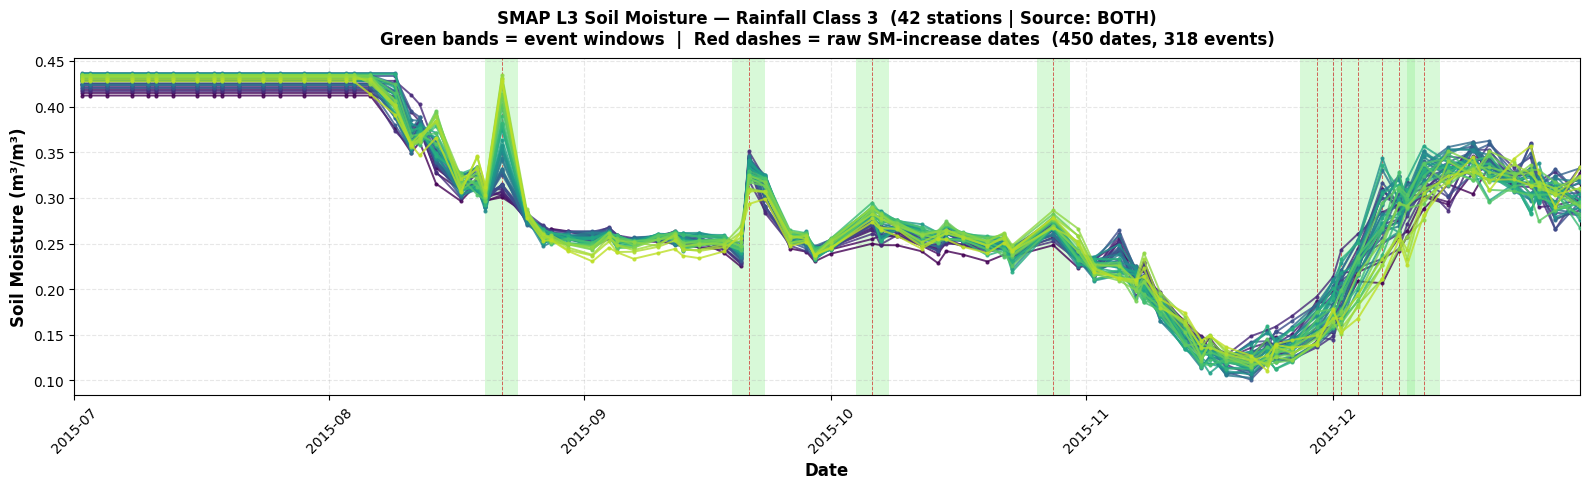

Class 3: 318 consecutive-increase event(s) | 450 raw increase dates | 1626 total window dates



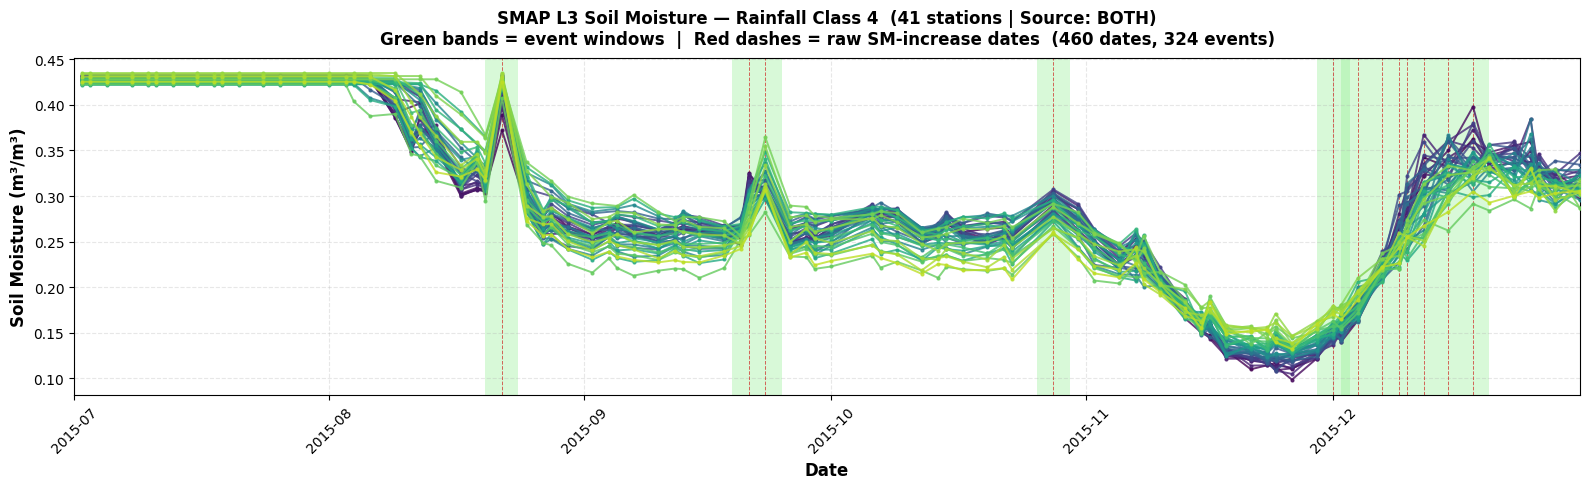

Class 4: 324 consecutive-increase event(s) | 460 raw increase dates | 1654 total window dates



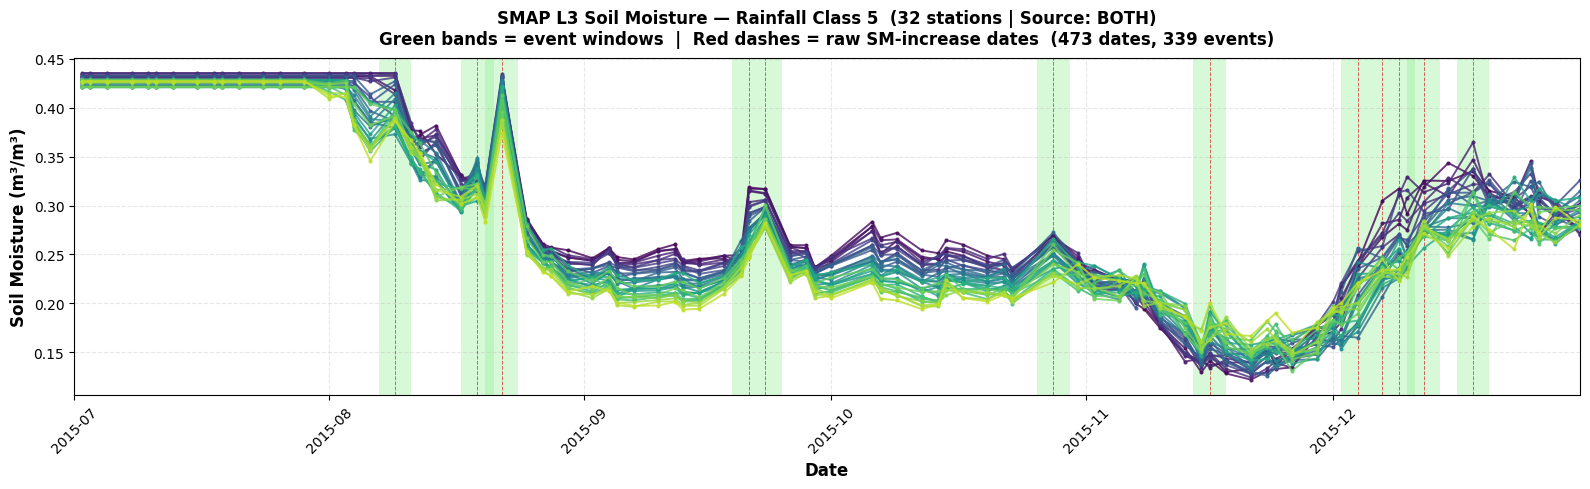

Class 5: 339 consecutive-increase event(s) | 473 raw increase dates | 1713 total window dates



In [23]:

# ── Colour palette matching the viewer notebook ───────────────────────────────
def station_colors(n):
    if n <= 10:
        return plt.cm.tab10(np.linspace(0, 1, 10))
    if n <= 20:
        return plt.cm.tab20(np.linspace(0, 1, 20))
    return plt.cm.viridis(np.linspace(0, 0.9, n))


# START_DATE_plot    = '2022-01-01'
# STOP_DATE_plot    = '2022-05-30'

START_DATE_plot    = '2015-07-01'
STOP_DATE_plot    = '2015-12-31'

# Convert configured date strings to Timestamps once (used for xlim + data filter)
plot_start = pd.Timestamp(START_DATE_plot)
plot_stop  = pd.Timestamp(STOP_DATE_plot)

for cls in classes:
    if cls not in results or len(results[cls]['final_dates']) == 0:
        print(f'Class {cls}: no calibration dates – skipping plot.')
        continue

    stations_in_class = class_stations[cls]          # station string keys
    if not stations_in_class:
        continue

    # ── Slice pivot to this class's stations and drop all-NaN rows ───────────
    ts_cls = ts_full[stations_in_class].dropna(how='all')

    # ── Restrict to configured date range (mirrors viewer data filter) ────────
    ts_cls = ts_cls[(ts_cls.index >= plot_start) & (ts_cls.index <= plot_stop)]

    if ts_cls.empty:
        # print(f'Class {cls}: no data in [{START_DATE}, {STOP_DATE}] – skipping plot.')
        continue

    # Re-build a long-format DataFrame identical to what the viewer creates
    # (date column as datetime, sm_mean per station-day).
    long_rows = []
    for stn_key in stations_in_class:
        if stn_key not in ts_cls.columns:
            continue
        s = ts_cls[stn_key].dropna().reset_index()
        s.columns = ['date', 'sm_mean']
        s['station'] = stn_key
        long_rows.append(s)

    if not long_rows:
        print(f'Class {cls}: no valid SM data – skipping plot.')
        continue

    ts_long = pd.concat(long_rows, ignore_index=True)

    # ── Events and calibration dates from results dict ────────────────────────
    events      = results[cls]['events']          # list of lists of Timestamps
    calib_dates = set(results[cls]['calib_dates'])
    final_dates = results[cls]['final_dates']

    n_stations   = len(stations_in_class)
    colors_arr   = station_colors(n_stations)

    fig, ax = plt.subplots(figsize=(16, 5))

    # ── 1 · Shade each event window (green) ─────────────────────────────────
    # The window spans from (event_start - DAYS_BEFORE_START) to
    # (event_end + DAYS_AFTER_END), clipped to the configured date range.
    for event in events:
        win_start = event[0]  - pd.Timedelta(days=DAYS_BEFORE_START)
        win_end   = event[-1] + pd.Timedelta(days=DAYS_AFTER_END)
        win_start = max(win_start, plot_start)
        win_end   = min(win_end,   plot_stop)
        if win_start > win_end:
            continue
        ax.axvspan(win_start, win_end,
                   color='#90EE90', alpha=0.35, linewidth=0, zorder=1)

    # ── 2 · Red dashed lines at raw SM-increase dates (flag = 1) ────────────
    for cd in sorted(calib_dates):
        if plot_start <= cd <= plot_stop:
            ax.axvline(cd, color='#CC0000', linewidth=0.7,
                       linestyle='--', alpha=0.6, zorder=2)

    # ── 3 · Per-station time series (viewer style) ────────────────────────────
    for idx, stn_key in enumerate(stations_in_class):
        stn_data = ts_long[ts_long['station'] == stn_key].sort_values('date')
        if stn_data.empty:
            continue
        lat_part, lon_part = stn_key.split('_')
        ax.plot(
            stn_data['date'], stn_data['sm_mean'],
            marker='o', markersize=2, linewidth=1.4, alpha=0.80,
            color=colors_arr[idx % len(colors_arr)],
            # label=f'({lat_part}°, {lon_part}°)',
            zorder=3,
        )

    # ── 4 · Formatting ────────────────────────────────────────────────────────
    ax.set_xlim(plot_start, plot_stop)           # enforce configured date range
    ax.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax.set_ylabel('Soil Moisture (m³/m³)', fontsize=12, fontweight='bold')
    ax.set_title(
        f'SMAP L3 Soil Moisture — Rainfall Class {cls}  '
        f'({n_stations} stations | Source: {SM_SOURCE})\n'
        f'Green bands = event windows  |  Red dashes = raw SM-increase dates  '
        f'({len(calib_dates)} dates, {len(events)} events)',
        fontsize=12, fontweight='bold', pad=10,
    )
    ax.grid(True, alpha=0.3, linestyle='--', zorder=0)
    ax.tick_params(axis='x', rotation=45)

    # if n_stations <= 20:
    #     ax.legend(fontsize=7, loc='best', ncol=2, framealpha=0.8)
    # else:
    #     print(f'  Class {cls}: legend omitted — too many stations ({n_stations}).')

    plt.tight_layout()
    plt.show()
    print(f'Class {cls}: {len(events)} consecutive-increase event(s) | '
          f'{len(calib_dates)} raw increase dates | '
          f'{len(final_dates)} total window dates\n')


## 10 · Sample Dates from Each Class CSV

In [24]:
for cls in classes:
    csv_path = OUTPUT_DIR / f'class_{cls}_calib_dates.csv'
    if not csv_path.exists():
        continue
    tmp = pd.read_csv(csv_path, parse_dates=['date', 'event_date'])
    print(f'── Class {cls} ── {len(tmp)} rows ──────────────────────────')
    print(tmp.head(10).to_string(index=False))
    print()


── Class 1 ── 1623 rows ──────────────────────────
event_date       date  offset_days  flag
2015-04-08 2015-04-06           -2     0
2015-04-08 2015-04-07           -1     0
2015-04-08 2015-04-08            0     1
2015-04-08 2015-04-09            1     0
2015-04-08 2015-04-10            2     0
2015-04-29 2015-04-27           -2     0
2015-04-29 2015-04-28           -1     0
2015-04-29 2015-04-29            0     1
2015-04-29 2015-04-30            1     0
2015-04-29 2015-05-01            2     0

── Class 2 ── 1771 rows ──────────────────────────
event_date       date  offset_days  flag
2015-04-08 2015-04-06           -2     0
2015-04-08 2015-04-07           -1     0
2015-04-08 2015-04-08            0     1
2015-04-08 2015-04-09            1     0
2015-04-08 2015-04-10            2     0
2015-04-16 2015-04-14           -2     0
2015-04-16 2015-04-15           -1     0
2015-04-16 2015-04-16            0     1
2015-04-16 2015-04-17            1     0
2015-04-16 2015-04-18            2  

## 11 · Save Consecutive SM-Increase Dates to `smap_consecutive_increase_dates/`

Each file contains only the **raw consecutive-increase dates** (no pre/post window padding) with two extra columns:

| Column | Description |
|--------|-------------|
| `date` | Observation date |
| `event_id` | 1-based integer identifying the consecutive-increase block |
| `event_length` | Number of consecutive observation days in that block |


## Summary

| Step | Action |
|------|--------|
| 3 | Loaded SMAP NC, removed fill values, built a **full date × station pivot table** |
| 4 | Loaded `smap_station_rainfall_class.csv` and mapped every station to its class (1–5) |
| 5 | Defined a reusable `detect_calibration_dates()` function that applies the spatial increase filter, groups consecutive days into events, and expands each event with a pre/post window |
| 6 | For **each class independently**: sliced the pivot to that class's stations, ran the detector with a **75 % threshold**, and saved results to `smap_calib_dates_per_class/class_<N>_calib_dates.csv` |
| 8–9 | Generated monthly bar-charts and a cross-class timeline visualisation |